In [1]:
import numpy as np
import networkx as nx
from collections import defaultdict

from QHyper.converter import Converter
from QHyper.constraint import Polynomial

from dwave.system import DWaveSampler
from dimod import BinaryQuadraticModel

from QHyper.problems.community_detection import CommunityDetectionProblem, Network


%load_ext autoreload
%autoreload 2

In [2]:
Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

In [3]:
from Qommunity.samplers.hierarchical.gurobi_sampler import GurobiSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher


gur = GurobiSampler(G)
it_searcher = IterativeSearcher(gur)
res = it_searcher.run_with_sampleset_info(num_runs=1, save_results=False)

comms = res.communities[0]
div_tree = res.division_tree[0]
div_mods = res.division_modularities[0]

100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


In [4]:
division_tree = div_tree
communities = comms
division_modularities = div_mods

In [5]:
class Node:
    def __init__(self, id, values, left=None, right=None, parent=None):
        self.id = id
        self.values = values
        self.left = left
        self.right = right
        self.parent = parent

    def __str__(self):
        return f"Node(id={self.id}, values={self.values})"
    
    def __repr__(self):
        return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
    def __eq__(self, node):
        if not isinstance(node, Node):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

class Tree:
    def __init__(self, root):
        self.root = root
        self.nodes = [root]

In [6]:
def recover_ordering(division_tree):
    root = Node(id=hash(tuple(G.nodes)), values=list(G.nodes), left=None, right=None, parent=None)
    nodes = {}

    for level in reversed(range(len(division_tree))):
        level_clustering = division_tree[level]

        if level == len(division_tree) - 1:
            for cluster in level_clustering:
                leaf_node = Node(id=hash(tuple(cluster)), values=cluster, left=None, right=None, parent=None)
                nodes[leaf_node.id] = leaf_node
        else:
            subsequent_clusters = division_tree[level + 1]
            subclusters = {}

            for subsequent_cluster in subsequent_clusters: # children clusters
                for cluster in level_clustering: # parent clusters
                    if set(subsequent_cluster).issubset(set(cluster)): # if subsequent cluster is child of the parent
                        key_clus = hash(tuple(cluster))
                        
                        if key_clus not in subclusters.keys():
                            subclusters[key_clus] = subsequent_cluster
                        else:
                            subclusters[key_clus] = (
                                subclusters.get(key_clus),
                                subsequent_cluster,
                            )                    

            for cluster in level_clustering:
                key_clus = hash(tuple(cluster))

                if type(subclusters[key_clus]) == tuple:
                    c0, c1 = subclusters[key_clus]
                    key1, key2 = hash(tuple(c0)), hash(tuple(c1))

                    child_node_1 = nodes[key1]
                    child_node_2 = nodes[key2]

                    parent_node = Node(id=key_clus, values=cluster, left=child_node_1, right=child_node_2, parent=None)
                    nodes[parent_node.id] = parent_node

                    child_node_1.parent = parent_node
                    child_node_2.parent = parent_node
                    
                    # Sanity checks
                    assert child_node_1.parent == parent_node
                    assert child_node_2.parent == parent_node


                # only one subcommunity - list
                elif type(subclusters[key_clus]) == list and level != 0:
                    pass # Nothing to do in here

    root = nodes[root.id]
    return nodes, root

In [7]:
nodes, root = recover_ordering(div_tree)

In [8]:
nodes

{4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 508968978265049823: Node(values=[0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96], left=None, right=None),
 7673536023032186979: Node(values=[34, 52, 94, 99], left=None, right=None),
 9094344604165242636: Node(values=[6, 90, 98], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 -1198255070108046162: Node(values=[12, 17, 35, 36, 40, 65, 67, 74, 79, 92], left=None, right=None),
 -2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 -2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 -4103333047921192956: Node(values=[19, 38, 41, 46, 49, 53, 76, 78, 80, 83], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),
 -8474

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    label = divide_label(node.values)
    mod_value = div_mods[level]
    color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves
    values = node.values

    # pr_id = comm_hash_to_pr_id[hash(tuple(values))]
    # chain_strength = pr_id_to_chain_strength[pr_id]
    # chain_strength = comm_hash_to_ch_str[hash(tuple(values))]
    chain_strength = 0.93

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level, chain_strength=chain_strength)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level + 1)

    
def center_parents(G, pos):
    """Center parents above children."""
    for n, data in sorted(G.nodes(data=True), key=lambda x: x[1]['level'], reverse=True):
        children = list(G.successors(n))
        if len(children) == 2:
            x1, _ = pos[children[0]]
            x2, _ = pos[children[1]]
            _, y = pos[n]
            pos[n] = ((x1 + x2)/2, y)
    return pos


def plot_tree(root):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    center_parents(G, pos)

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    plt.figure(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           alpha=0.6)

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        color = node_data['color']
        values = node_data['values']
        chain_strength = node_data['chain_strength']

        # label = f"{len(values)}\n{mod_value:.2f}"
        text_color = "white" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        label2 = f"Ch.str.: {chain_strength}"
        label = label1 + "\n" + label2

        # plt.text(x, y,
        #          label1,
        #          ha="center", va="center",
        #         #  ha="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        # plt.text(x, y-30,
        #          label2,
        #          ha="center", va="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        plt.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


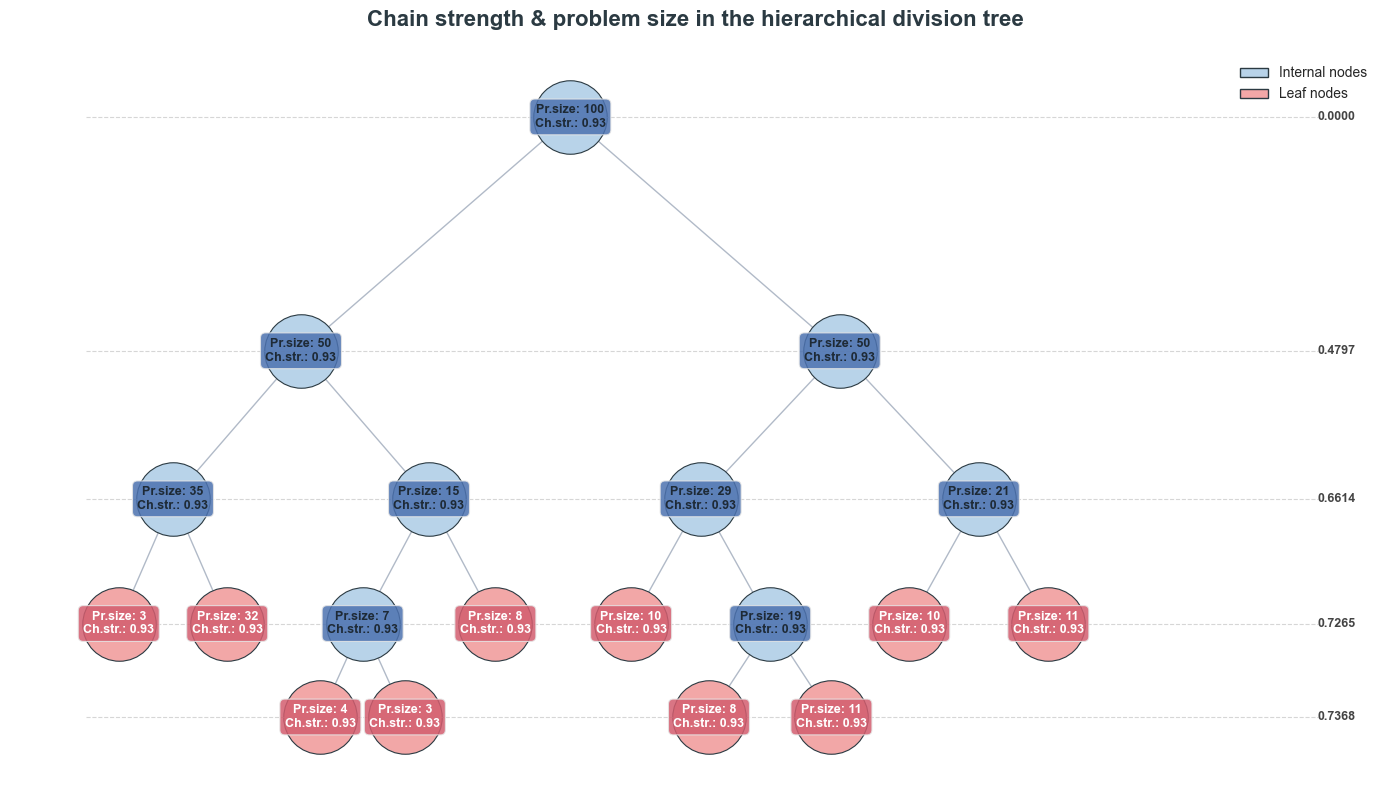

In [10]:
plot_tree(root)

In [11]:
nodes

{4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 508968978265049823: Node(values=[0, 4, 9, 11, 13, 18, 21, 23, 26, 27, 32, 39, 42, 44, 45, 47, 48, 50, 55, 56, 57, 58, 64, 71, 77, 81, 85, 87, 89, 93, 95, 96], left=None, right=None),
 7673536023032186979: Node(values=[34, 52, 94, 99], left=None, right=None),
 9094344604165242636: Node(values=[6, 90, 98], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 -1198255070108046162: Node(values=[12, 17, 35, 36, 40, 65, 67, 74, 79, 92], left=None, right=None),
 -2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 -2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 -4103333047921192956: Node(values=[19, 38, 41, 46, 49, 53, 76, 78, 80, 83], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),
 -8474

In [12]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher

In [13]:
adv_sampler = AdvantageSampler(G, num_reads=100, version="Advantage2_system1.7", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)

In [14]:
searcher = HierarchicalSearcher(adv_sampler)
res_adv = searcher.hierarchical_community_search(division_tree=True, return_modularities=True, return_metadata=True)

Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' ob

In [15]:
communities = res_adv[0]
division_tree = res_adv[1]
division_modularities = res_adv[2]
sampleset_metadata = res_adv[3]

In [16]:
sampleset_metadata.timing[0]

{'qpu_sampling_time': 24068.0,
 'qpu_anneal_time_per_sample': 20.0,
 'qpu_readout_time_per_sample': 200.1,
 'qpu_access_time': 39835.16,
 'qpu_access_overhead_time': 1095.84,
 'qpu_programming_time': 15767.16,
 'qpu_delay_time_per_sample': 20.58,
 'post_processing_overhead_time': 29.0,
 'total_post_processing_time': 29.0}

In [17]:
sampleset_metadata.community_hash

[4479737025582696436,
 2827978857727793897,
 5827654665522894283,
 -2251870041769838549,
 657654672818871423,
 8017710799782698310,
 -2045999771114126478,
 8382116278564893749,
 -6597898653765179345,
 7257540054485854263,
 -874311280003140379,
 -5921050210639668839,
 -3293036671993735008,
 8558532842210876714,
 3403369474371264611,
 5549611767240682781,
 5115602138742073863,
 4244552301997251146,
 6856301404787791340,
 -6539798361249740001,
 -1307218551505081459,
 7673536023032186979,
 -7568613258422254152]

In [18]:
nodes, root = recover_ordering(division_tree)

In [32]:
nodes

{-2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 8017710799782698310: Node(values=[19, 38, 41, 46, 49, 76, 78, 80], left=None, right=None),
 -2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),
 -874311280003140379: Node(values=[9, 64], left=None, right=None),
 -5921050210639668839: Node(values=[6, 12, 17, 35, 36, 40, 65, 67, 74, 79, 90, 92, 98], left=None, right=None),
 3403369474371264611: Node(values=[0, 4, 11, 13, 18, 21, 23, 26, 27, 32, 39, 44, 45, 47, 50, 55, 56, 57, 58, 71, 77, 81, 85, 87, 89, 93, 95, 96], left=None, right=None),
 5115602138742073863: Node(values=[42, 48], left=None, right=None),
 4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 7673536023032186979: Node(val

In [33]:
def print_tree(node, level=0):
    if node is not None:
        print_tree(node.right, level + 1)
        print(' ' * 8 * level + '->', node)
        print_tree(node.left, level + 1)

In [34]:
print_tree(root)

                                -> Node(id=-7568613258422254152, values=[53, 83])
                        -> Node(id=-1307218551505081459, values=[34, 52, 53, 83, 94, 99])
                                -> Node(id=7673536023032186979, values=[34, 52, 94, 99])
                -> Node(id=6856301404787791340, values=[5, 10, 25, 28, 30, 31, 34, 52, 53, 60, 69, 83, 94, 99])
                        -> Node(id=-6539798361249740001, values=[5, 10, 25, 28, 30, 31, 60, 69])
        -> Node(id=-3293036671993735008, values=[0, 4, 5, 10, 11, 13, 18, 20, 21, 22, 23, 25, 26, 27, 28, 30, 31, 32, 34, 39, 42, 44, 45, 47, 48, 50, 52, 53, 55, 56, 57, 58, 60, 68, 69, 71, 77, 81, 83, 85, 87, 89, 93, 94, 95, 96, 99])
                                -> Node(id=4244552301997251146, values=[20, 22, 68])
                        -> Node(id=5549611767240682781, values=[20, 22, 42, 48, 68])
                                -> Node(id=5115602138742073863, values=[42, 48])
                -> Node(id=85585328422108767

In [35]:
from enum import Enum
from QHyper.solvers.base import SamplesetData
from dataclasses import dataclass, field
import numpy as np
from typing import Union, List, Dict, Any

In [23]:
# from searchers.utils import MetadataFieldName

# # class Node:
# #     def __init__(self, id, values, left=None, right=None, parent=None):
# #         self.id = id
# #         self.values = values
# #         self.left = left
# #         self.right = right
# #         self.parent = parent

# #     def __str__(self):
# #         return f"Node(id={self.id}, values={self.values})"
    
# #     def __repr__(self):
# #         return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
# #     def __eq__(self, node):
# #         if not isinstance(node, Node):
# #             return False
# #         return self.id == node.id and sorted(self.values) == sorted(node.values)

# # class Tree:
# #     def __init__(self, root):
# #         self.root = root
# #         self.nodes = [root]


# # class DivisionNode:
# #     def __init__(self, community_hash, values, problem_id, chain_strength, chain_break_fraction, left=None, right=None, parent=None):
# #         self.id = community_hash
# #         self.values = values
# #         self.left = left
# #         self.right = right
# #         self.parent = parent

# #         # Additional data
# #         self.community_hash = community_hash
# #         self.problem_id = problem_id
# #         self.chain_strength = chain_strength
# #         self.chain_break_fraction = chain_break_fraction


# #     def __str__(self):
# #         return f"Node(id={self.id}, values={self.values})"
    
# #     def __repr__(self):
# #         return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
# #     def __eq__(self, node):
# #         if not isinstance(node, DivisionNode):
# #             return False
# #         return self.id == node.id and sorted(self.values) == sorted(node.values)


# @dataclass
# class HierarchicalRunMetadata:
#     dwave_sampleset_metadata: np.recarray = field(init=False)
#     time_measurements: np.recarray = field(init=False)
#     dwave_sampleset: List[Dict[str, Any]] = field(init=False)
#     timing: List[Dict[str, Any]] = field(init=False)
#     problem_id: List[Union[str, int, float]] = field(init=False)
#     community_hash: List[Union[str, int]] = field(init=False)
#     chain_strength: List[float] = field(init=False)
#     chain_break_fraction: List[float] = field(init=False)
#     chain_break_method: List[str] = field(init=False)
#     embedding: List[Dict[str, Any]] = field(init=False)
#     warnings: List[Dict[str, Any]] = field(init=False)

#     def __init__(self, sampleset: List[SamplesetData]):
#         self.dwave_sampleset_metadata = self._process_samples(
#             sampleset, MetadataFieldName.DwaveSamplesetMetadata.value
#         )
#         self.time_measurements = self._process_samples(
#             sampleset, MetadataFieldName.TimeMeasurements.value
#         )
#         self.dwave_sampleset = self._process_samples(
#             sampleset, MetadataFieldName.DWaveSampleset.value
#         )
#         self.timing = self._process_samples(
#             sampleset, MetadataFieldName.Timing.value
#         )
#         self.problem_id = self._process_samples(
#             sampleset, MetadataFieldName.ProblemID.value
#         )
#         self.community_hash = self._process_samples(
#             sampleset, MetadataFieldName.CommunityHash.value
#         )
#         self.chain_strength = self._process_samples(
#             sampleset, MetadataFieldName.ChainStrength.value
#         )
#         self.chain_break_fraction = self._process_samples(
#             sampleset, MetadataFieldName.ChainBreakFraction.value
#         )
#         self.chain_break_method = self._process_samples(
#             sampleset, MetadataFieldName.ChainBreakMethod.value
#         )
#         self.embedding = self._process_samples(
#             sampleset, MetadataFieldName.Embedding.value
#         )
#         self.warnings = self._process_samples(
#             sampleset, MetadataFieldName.Warnings.value
#         )


In [36]:
class DivisionNode:
    def __init__(self, community_hash: str | int, node: Node, sampleset_data: SamplesetData):
        self.community_hash: int | str = community_hash
        self.node: Node = node
        self.sampleset_data: SamplesetData = sampleset_data
        
    @property
    def id(self):
        return self.node.id

    @property
    def values(self):
        return self.node.values
    
    @property
    def left(self):
        return self.node.left
    
    @property
    def right(self):
        return self.node.right
    
    @property
    def parent(self):
        return self.node.parent
    
    @property
    def problem_id(self):
        return self.sampleset_data.problem_id
    
    @property
    def chain_strength(self):
        return self.sampleset_data.chain_strength
    
    @property
    def chain_break_fraction(self):
        return self.sampleset_data.chain_break_fraction
    
    @property
    def chain_break_method(self):
        return self.sampleset_data.chain_break_method
    
    def __str__(self):
        return f"ExtendedNode(id={self.id}, community={self.values})"
    
    def __repr__(self):
        return f"ExtendedNode(community={self.values}, left={self.left}, right={self.right}, community_hash={self.community_hash}, problem_id={self.problem_id}, chain_strength={self.chain_strength}, chain_break_fraction={self.chain_break_fraction}, chain_break_method={self.chain_break_method})"
    
    def __eq__(self, node):
        if not isinstance(node, DivisionNode):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

In [25]:
4817272892292364285 == 4817272892292364285

True

In [37]:
len(nodes)

23

In [38]:
nodes, root = recover_ordering(division_tree)

In [39]:
nodes

{-2251870041769838549: Node(values=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None),
 8017710799782698310: Node(values=[19, 38, 41, 46, 49, 76, 78, 80], left=None, right=None),
 -2045999771114126478: Node(values=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None),
 7257540054485854263: Node(values=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None),
 -874311280003140379: Node(values=[9, 64], left=None, right=None),
 -5921050210639668839: Node(values=[6, 12, 17, 35, 36, 40, 65, 67, 74, 79, 90, 92, 98], left=None, right=None),
 3403369474371264611: Node(values=[0, 4, 11, 13, 18, 21, 23, 26, 27, 32, 39, 44, 45, 47, 50, 55, 56, 57, 58, 71, 77, 81, 85, 87, 89, 93, 95, 96], left=None, right=None),
 5115602138742073863: Node(values=[42, 48], left=None, right=None),
 4244552301997251146: Node(values=[20, 22, 68], left=None, right=None),
 -6539798361249740001: Node(values=[5, 10, 25, 28, 30, 31, 60, 69], left=None, right=None),
 7673536023032186979: Node(val

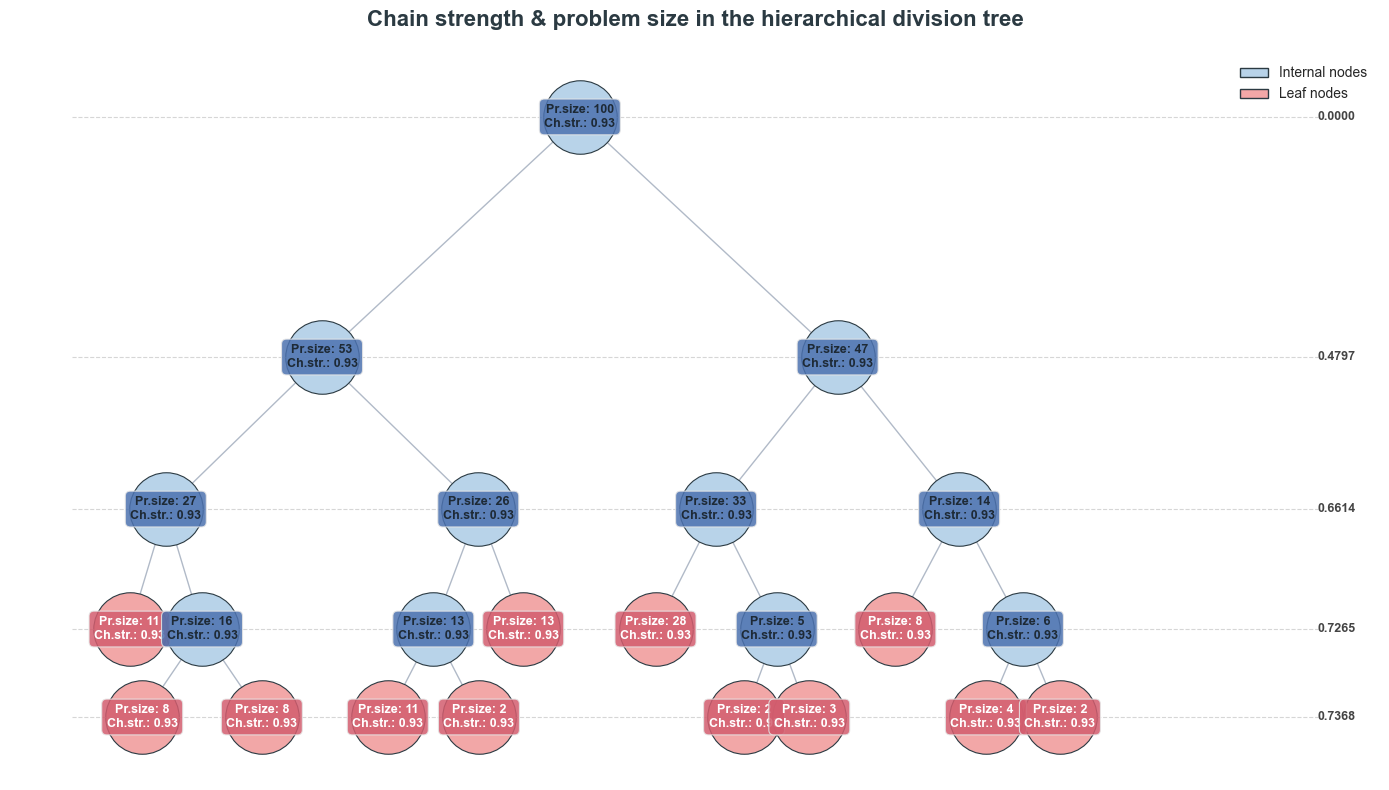

In [40]:
plot_tree(root)

In [41]:
len(nodes)

23

In [42]:
len(sampleset_metadata)

23

In [66]:
sampleset_metadata.community_hash

[4479737025582696436,
 612469097260748481,
 8354775787335185367,
 -5912280283038680689,
 1728070064422458578,
 -5921050210639668839,
 7516886752711722943,
 2639865646935670784,
 4244552301997251146,
 7673536023032186979,
 -6481635584240371785,
 7543149240429601414,
 5115602138742073863,
 -531133161866166759,
 9216918474526124130,
 -979107516685483635,
 -2045999771114126478,
 5998891798953776509,
 -6539798361249740001,
 -1781945651135785683,
 7257540054485854263,
 -4103333047921192956]

In [43]:
sampleset_metadata

HierarchicalRunMetadata(dwave_sampleset_metadata=rec.array([(24068., 20., 200.1 , 39835.16, 1095.84, 15767.16, 20.58,  29.,  29.),
           (13784., 20.,  97.26, 29545.96,  574.04, 15761.96, 20.58,   1.,   1.),
           (20884., 20., 168.26, 36644.36,  504.64, 15760.36, 20.58,  36.,  36.),
           (12676., 20.,  86.18, 28436.36, 1260.64, 15760.36, 20.58,   1.,   1.),
           (19816., 20., 157.58, 35576.36, 1294.64, 15760.36, 20.58,   1.,   1.),
           (12500., 20.,  84.42, 28261.16, 1483.84, 15761.16, 20.58,  39.,  39.),
           (12500., 20.,  84.42, 28261.16, 1396.84, 15761.16, 20.58,   1.,   1.),
           (20884., 20., 168.26, 36645.16, 1222.84, 15761.16, 20.58,   1.,   1.),
           (14990., 20., 109.32, 30750.36,  739.64, 15760.36, 20.58,  24.,  24.),
           (12676., 20.,  86.18, 28437.56, 1367.44, 15761.56, 20.58,  50.,  50.),
           ( 6604., 20.,  25.46, 22364.76, 1639.24, 15760.76, 20.58,  26.,  26.),
           (14990., 20., 109.32, 30750.76,  713.2

In [45]:
extended_nodes = {nodes_k: DivisionNode(community_hash=None, node=node, sampleset_data=sampleset_metadata[nodes_k]) for nodes_k, node in nodes.items()}
extended_nodes

{-2251870041769838549: ExtendedNode(community=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None, community_hash=None, problem_id=619bf6b3-1141-40bb-9c57-55e6ed8bc2ec, chain_strength=0.918270849678021, chain_break_fraction=0.0, chain_break_method=majority_vote),
 8017710799782698310: ExtendedNode(community=[19, 38, 41, 46, 49, 76, 78, 80], left=None, right=None, community_hash=None, problem_id=f29a1f7c-a08c-4f92-a89f-0f567f7b3510, chain_strength=0.8989640657322797, chain_break_fraction=0.0, chain_break_method=majority_vote),
 -2045999771114126478: ExtendedNode(community=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None, community_hash=None, problem_id=5c86597d-e07d-4614-a1ef-3e058d528056, chain_strength=0.8942910530177813, chain_break_fraction=0.0, chain_break_method=majority_vote),
 7257540054485854263: ExtendedNode(community=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None, community_hash=None, problem_id=dfc86a63-804b-47c7-8a1c-917bf1275686, chai

In [46]:
for _, v in extended_nodes.items():
    if v.left:
        v.node.left = extended_nodes[v.left.id]
    if v.right:
        v.node.right = extended_nodes[v.right.id]
    if v.parent:
        v.node.parent = extended_nodes[v.parent.id]

In [47]:
extended_nodes

{-2251870041769838549: ExtendedNode(community=[2, 14, 15, 16, 33, 43, 54, 73, 86, 88, 91], left=None, right=None, community_hash=None, problem_id=619bf6b3-1141-40bb-9c57-55e6ed8bc2ec, chain_strength=0.918270849678021, chain_break_fraction=0.0, chain_break_method=majority_vote),
 8017710799782698310: ExtendedNode(community=[19, 38, 41, 46, 49, 76, 78, 80], left=None, right=None, community_hash=None, problem_id=f29a1f7c-a08c-4f92-a89f-0f567f7b3510, chain_strength=0.8989640657322797, chain_break_fraction=0.0, chain_break_method=majority_vote),
 -2045999771114126478: ExtendedNode(community=[1, 3, 7, 8, 24, 72, 84, 97], left=None, right=None, community_hash=None, problem_id=5c86597d-e07d-4614-a1ef-3e058d528056, chain_strength=0.8942910530177813, chain_break_fraction=0.0, chain_break_method=majority_vote),
 7257540054485854263: ExtendedNode(community=[29, 37, 51, 59, 61, 62, 63, 66, 70, 75, 82], left=None, right=None, community_hash=None, problem_id=dfc86a63-804b-47c7-8a1c-917bf1275686, chai

In [48]:
sampleset_metadata.chain_strength

[0.9556174135489324,
 0.9338451051918749,
 0.9310686681068997,
 0.918270849678021,
 0.9161160294479842,
 0.8989640657322797,
 0.8942910530177813,
 0.9059690543428899,
 0.8826310527145695,
 0.9114075996526694,
 None,
 0.9206002396612722,
 0.8659980033676796,
 0.8426717384363325,
 0.837620884582425,
 0.7642380931717486,
 None,
 None,
 0.8659840187954401,
 0.9088431561707252,
 0.8032371495770732,
 None,
 None]

In [49]:
root_extended = DivisionNode(community_hash=root.id, node=root, sampleset_data=sampleset_metadata[root.id])

In [50]:
comms = communities
div_tree = division_tree
div_mods = division_modularities

In [260]:
sampleset_metadata.dwave_sampleset

[SampleSet(rec.array([([1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1], -45.37373737, 1, 0.01),
            ([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0], -44.47979798, 1, 0.01),
            ([1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1

In [59]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def build_graph_extended(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""

    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)
    
    community_hash = node.community_hash
    community = node.values
    problem_id = node.problem_id
    chain_strength = node.chain_strength
    chain_break_fraction = node.chain_break_fraction

    label = divide_label(node.values)
    mod_value = div_mods[level]
    # color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves


    G.add_node(node.id, label=label, mod_value=mod_value, values=community, level=level, chain_strength=chain_strength, chain_break_fraction=chain_break_fraction, community_hash=community_hash, problem_id=problem_id)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph_extended(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph_extended(G, node.right, level + 1)

In [295]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm


ROUND_DIGITS = 4


def center_parents(G, pos):
    """Center parents above children."""
    for n, data in sorted(G.nodes(data=True), key=lambda x: x[1]['level'], reverse=True):
        children = list(G.successors(n))
        if len(children) == 2:
            x1, _ = pos[children[0]]
            x2, _ = pos[children[1]]
            _, y = pos[n]
            pos[n] = ((x1 + x2)/2, y)
    return pos


def plot_tree_extended(root, figsize=(14,8), cmap=plt.cm.viridis, value=None):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph_extended(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    center_parents(G, pos)

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    # plt.figure(figsize=figsize)
    fig, ax = plt.subplots(figsize=figsize)
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           ax=ax,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           ax=ax,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           ax=ax,
                           alpha=0.6)
    


    cmap = cmap
    values = [G.nodes[n]['chain_strength'] for n in G.nodes()]
    valid_values = [v for v in values if v is not None]
    norm = mcolors.Normalize(vmin=min(valid_values), vmax=max(valid_values))
    # none_color = "#d3d3d3"
    none_color = "#CE6060"
    colors = {v: mcolors.to_hex(cmap(norm(v))) if v is not None else none_color for v in values}

    import math

    def is_bright(rgb, threshold=240):
        r, g, b = rgb
        lum = 0.2126*r + 0.7152*g + 0.0722*b
        return lum >= threshold
    
    def is_close_to_white(rgb, threshold=30):
        """
        rgb: (R, G, B) tuple, 0–255
        threshold: max distance from white to be considered 'close'
        """
        r, g, b = rgb
        # Euclidean distance to white
        dist = math.sqrt((255 - r)**2 + (255 - g)**2 + (255 - b)**2)
        return dist < threshold
    
    def is_close_to_gray(color_hex, sat_threshold=0.15):
        """
        Returns True if color is low saturation (grayish/whitish)
        color_hex: "#rrggbb"
        sat_threshold: maximum saturation allowed to still be considered 'gray'
        """
        rgb = mcolors.to_rgb(color_hex)
        h, s, v = mcolors.rgb_to_hsv(rgb)
        return s < sat_threshold

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']

        color = colors[node_data['chain_strength']]
        color_rgb = mcolors.to_rgb(color)
        rgb_255 = tuple(int(255 * x) for x in color_rgb)

        # if is_close_to_white(rgb_255, 30):
        # if is_bright(rgb_255, 200):
        if is_close_to_gray(color, sat_threshold=0.4):
            text_color = "#1e2a36"  # dark text for bright backgrounds
        else:
            text_color = "white"  # light text for dark backgrounds


        values = node_data['values']
        chain_strength = node_data['chain_strength']
        chain_break_fraction = node_data['chain_break_fraction']

        # label = f"{len(values)}\n{mod_value:.2f}"
        # text_color = "white" if node in leaves else "#1e2a36"
        # text_color = "white"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        ch_str_label = f"{chain_strength:.3f}" if chain_strength is not None else chain_strength
        label2 = f"Ch.str.: {ch_str_label}"
        label3 = f"CBF: {chain_break_fraction:.3f}"
        # label = label1 + "\n" + label2
        label = label1 + "\n" + label2 + "\n" + label3

        ax.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx/2, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx), xmax=xmax+dx/2,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)
    


    # extended_colors = [none_color] + [cmap(i) for i in np.linspace(0, 1, 256)]
    # extended_cmap = ListedColormap(extended_colors)
    
    # sm = plt.cm.ScalarMappable(cmap=extended_cmap, norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.02)
    # ticks = ["None"] + sorted(set(valid_values))
    # cbar.set_ticks(ticks)
    # cbar.set_ticklabels([f"{t:.4f}" if t is not None else "None" for t in ticks])
    # cbar.set_label("Chain Strength", fontsize=10)
    
    # color_array = [cmap(i) for i in np.linspace(0, 1, 256)]
    # extended_colors = [mcolors.to_rgba(none_color)] + color_array
    # extended_cmap = ListedColormap(extended_colors)

    # # Normalization: 0 = None, numeric values from 0.0001 upwards
    # vmin, vmax = 0, max(valid_values)
    # norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # # Create ScalarMappable
    # sm = plt.cm.ScalarMappable(cmap=extended_cmap, norm=norm)
    # sm.set_array([])

    # # Plot colorbar
    # cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height]
    # cbar = plt.colorbar(sm, ax=ax, cax=cbar_ax, orientation="horizontal")

    # # Numeric ticks only! Map None to 0
    # ticks = [0] + list(np.linspace(min(valid_values), max(valid_values), 5))
    # cbar.set_ticks(ticks)
    # cbar.set_ticklabels(["None"] + [f"{t:.3f}" for t in ticks[1:]])
    # cbar.set_label("Chain strength", fontsize=10)

    valid_values_sorted = sorted(valid_values)

    # Create colormap
    cmap_vals = plt.cm.PuBu(np.linspace(0, 1, len(valid_values_sorted)))
    colors = np.vstack([mcolors.to_rgba(none_color), cmap_vals])
    discrete_cmap = ListedColormap(colors)

    # Create boundaries: first bin = None
    bounds = [-0.01] + valid_values_sorted
    norm = BoundaryNorm(bounds, discrete_cmap.N)

    # ScalarMappable
    sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)
    sm.set_array([])

    # Colorbar
    # fig, ax = plt.subplots(figsize=(6,1))
    cbar = plt.colorbar(sm, ax=ax, orientation="vertical")

    # Ticks
    ticks = [0] + valid_values_sorted
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(["None"] + [f"{t:.3f}" for t in valid_values_sorted])
    cbar.set_label("Chain Strength", fontsize=10, labelpad=20)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    # plt.axis("off")
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel("Modularity")
    ax.yaxis.set_label_position("right") 
    plt.tight_layout()
    # plt.show()

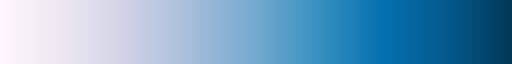

In [97]:
from matplotlib import colormaps
cmap = colormaps.get_cmap("PuBu")
cmap

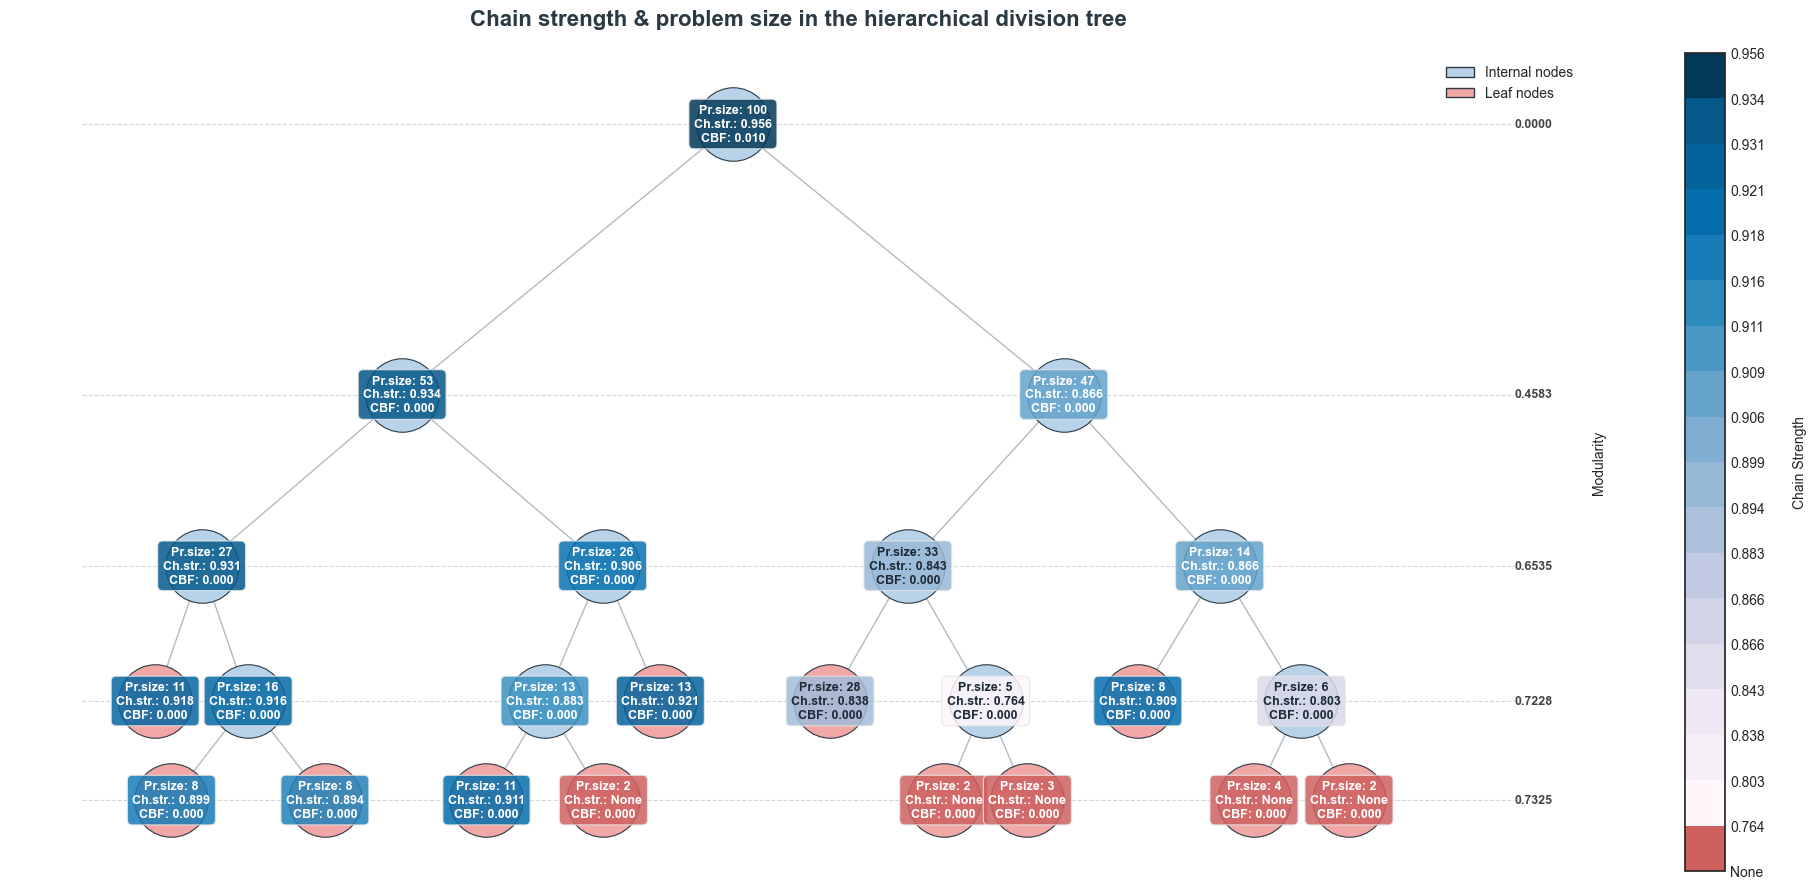

In [296]:
plot_tree_extended(root_extended, figsize=(20,9), cmap=cmap)

In [302]:
sampleset_metadata[0]

KeyError: "Index must be community_hash in this method. Community hash '0' not found"

In [ ]:
sorted(sampleset_metadata, key=lambda x: len(x.values))

SamplesetData(dwave_sampleset_metadata=np.record((6604.0, 20.0, 25.46, 22364.76, 1639.24, 15760.76, 20.58, 26.0, 26.0), dtype=[('qpu_sampling_time_us', '<f8'), ('qpu_anneal_time_per_sample_us', '<f8'), ('qpu_readout_time_per_sample_us', '<f8'), ('qpu_access_time_us', '<f8'), ('qpu_access_overhead_time_us', '<f8'), ('qpu_programming_time_us', '<f8'), ('qpu_delay_time_per_sample_us', '<f8'), ('post_processing_overhead_time_us', '<f8'), ('total_post_processing_time_us', '<f8')]), time_measurements=np.record((0.17384569998830557, 0.031969300005584955, 2.719476600002963), dtype=[('find_clique_embedding_time_TimeUnits.S', '<f8'), ('fixed_embedding_composite_time_TimeUnits.S', '<f8'), ('sample_func_time_TimeUnits.S', '<f8')]), dwave_sampleset=SampleSet(rec.array([([0, 0], 0., 56, 0.), ([1, 1], 0., 44, 0.)],
          dtype=[('sample', 'i1', (2,)), ('energy', '<f8'), ('num_occurrences', '<i8'), ('chain_break_fraction', '<f8')]), Variables(['x9', 'x64']), {'timing': {'qpu_sampling_time': 6604.0

In [261]:
sampleset_metadata

HierarchicalRunMetadata(dwave_sampleset_metadata=rec.array([(24068., 20., 200.1 , 39835.16, 1095.84, 15767.16, 20.58,  29.,  29.),
           (13784., 20.,  97.26, 29545.96,  574.04, 15761.96, 20.58,   1.,   1.),
           (20884., 20., 168.26, 36644.36,  504.64, 15760.36, 20.58,  36.,  36.),
           (12676., 20.,  86.18, 28436.36, 1260.64, 15760.36, 20.58,   1.,   1.),
           (19816., 20., 157.58, 35576.36, 1294.64, 15760.36, 20.58,   1.,   1.),
           (12500., 20.,  84.42, 28261.16, 1483.84, 15761.16, 20.58,  39.,  39.),
           (12500., 20.,  84.42, 28261.16, 1396.84, 15761.16, 20.58,   1.,   1.),
           (20884., 20., 168.26, 36645.16, 1222.84, 15761.16, 20.58,   1.,   1.),
           (14990., 20., 109.32, 30750.36,  739.64, 15760.36, 20.58,  24.,  24.),
           (12676., 20.,  86.18, 28437.56, 1367.44, 15761.56, 20.58,  50.,  50.),
           ( 6604., 20.,  25.46, 22364.76, 1639.24, 15760.76, 20.58,  26.,  26.),
           (14990., 20., 109.32, 30750.76,  713.2

In [141]:
div_mods

[0.0,
 0.4797469645954495,
 0.6614121008060402,
 0.7265074992347721,
 0.7367615549433733]

In [121]:
fe = ["sampleset_adv.pkl", "sampleset_adv_serializable.pkl", "sampleset_adv.npy"]

In [145]:
import os
import re


hashes = list(nodes.keys())

result_files = []
result_files_handles = []
for root, dirs, files in os.walk("."):
    for file in files:
        match = re.search(r"comm_hash=(.*?)__id", file)
        if match:
            comm_hash = int(match.group(1))
            # pattern = rf"^.*comm_hash={comm_hash}.*_sampleset_adv.pkl$"
            pattern = rf"^.*comm_hash={comm_hash}.*"
            result_handle = re.search(pattern, file)
            if result_handle:
                # result_handle = re.split(rf"(_{fe[0]})$", result_handle.group(0))
                result_handle = re.split("sampleset", result_handle.group(0))
                if comm_hash in hashes:
                    result_files.append(os.path.join(root, file))
                    result_files_handles.append(result_handle[0])

In [146]:
result_files_handles

['n=100_comm_hash=-1119365825242883868__id=2d866f96-6ad1-4eb0-8e3b-86905c990246_',
 'n=100_comm_hash=-1119365825242883868__id=2d866f96-6ad1-4eb0-8e3b-86905c990246_',
 'n=100_comm_hash=-1119365825242883868__id=2d866f96-6ad1-4eb0-8e3b-86905c990246_',
 'n=100_comm_hash=-1211315125366653896__id=3aefc9ac-6375-4077-b8dc-2bb2eff72e59_',
 'n=100_comm_hash=-1211315125366653896__id=3aefc9ac-6375-4077-b8dc-2bb2eff72e59_',
 'n=100_comm_hash=-1211315125366653896__id=3aefc9ac-6375-4077-b8dc-2bb2eff72e59_',
 'n=100_comm_hash=-2045999771114126478__id=e2d0f352-68d1-4cec-9aa7-661f8eb9c933_',
 'n=100_comm_hash=-2045999771114126478__id=e2d0f352-68d1-4cec-9aa7-661f8eb9c933_',
 'n=100_comm_hash=-2045999771114126478__id=e2d0f352-68d1-4cec-9aa7-661f8eb9c933_',
 'n=100_comm_hash=-2251870041769838549__id=63b0b6e4-6f4d-4f08-864a-b9fb66dd0d2e_',
 'n=100_comm_hash=-2251870041769838549__id=63b0b6e4-6f4d-4f08-864a-b9fb66dd0d2e_',
 'n=100_comm_hash=-2251870041769838549__id=63b0b6e4-6f4d-4f08-864a-b9fb66dd0d2e_',
 'n=

In [ ]:
sampleset_metadata.

HierarchicalRunMetadata(dwave_sampleset_metadata=rec.array([(24068., 20., 200.1 , 39831.56,   676.44, 15763.56, 20.58, 28., 28.),
           (19628., 20., 155.7 , 35393.16,   662.84, 15765.16, 20.58, 61., 61.),
           (20296., 20., 162.38, 36058.76,   638.24, 15762.76, 20.58,  1.,  1.),
           (14990., 20., 109.32, 30752.36,   604.64, 15762.36, 20.58,  1.,  1.),
           (12500., 20.,  84.42, 28263.56,   653.44, 15763.56, 20.58, 23., 23.),
           (21496., 20., 174.38, 37258.76,   590.24, 15762.76, 20.58,  1.,  1.),
           (20470., 20., 164.12, 36232.36,   607.64, 15762.36, 20.58,  1.,  1.),
           (20884., 20., 168.26, 36646.36,   550.64, 15762.36, 20.58,  1.,  1.),
           ( 6604., 20.,  25.46, 22366.76,  1894.24, 15762.76, 20.58, 27., 27.),
           (10628., 20.,  65.7 , 26390.36, 20783.64, 15762.36, 20.58,  1.,  1.),
           (13444., 20.,  93.86, 29208.36,   590.64, 15764.36, 20.58,  1.,  1.),
           (20296., 20., 162.38, 36058.76,  1321.24, 15762.7

In [149]:
np.load(result_files[0], allow_pickle=True)

TypeError: EmbeddedStructure is immutable